In [6]:
# PASO 1: Configurar el Entorno y Reproducibilidad
set.seed(42)       # Asegura que los números aleatorios sean siempre los mismos
n_sim <- 10000     # Número de escenarios / iteraciones solicitadas

In [9]:
# PASO 2: Generar las Variables Aleatorias (CORREGIDO Y SEGURO)
# Variable 1: Ventas Anuales 2026 -> Distribución Normal
ventas <- rnorm(n_sim, mean = 1200000, sd = 150000)

# Variable 2: Costo Variable % -> Distribución Uniforme
costo_var_pct <- runif(n_sim, min = 0.38, max = 0.48)
# Variable 3: Costos Fijos -> Distribución Triangular (Solución nativa sin errores)
# Min = 280,000 | Modo = 310,000 | Max = 340,000
u <- runif(n_sim)
costos_fijos <- ifelse(u < (310000 - 280000) / (340000 - 280000),
                       280000 + sqrt(u * (340000 - 280000) * (310000 - 280000)),
                       340000 - sqrt((1 - u) * (340000 - 280000) * (340000 - 310000)))

# Variable 4: Tasa de Impuesto (ISR) -> Constante
tasa_isr <- 0.30

In [16]:
# PASO 3: Calcular el Modelo Determinístico (La Ecuación) - CORREGIDO
# 1. Calculamos primero los costos variables totales
costos_variables_totales <- ventas * costo_var_pct

# 2. Calculamos la utilidad operativa (sin la "s" para evitar errores)
utilidad_operativa <- ventas - costos_variables_totales - costos_fijos

# 3. Calculamos la utilidad neta final aplicando el ISR
utilidad_neta <- utilidad_operativa * (1 - tasa_isr)

# Agrupamos todos los escenarios en un dataframe limpio
resultados <- data.frame(
  Ventas = ventas,
  CostoVarPct = costo_var_pct,
  CostosFijos = costos_fijos,
  UtilidadNeta = utilidad_neta
)

In [17]:
# PASO 4: Estadísticas Clave y Probabilidad de Éxito
media_utilidad <- mean(resultados$UtilidadNeta)
mediana_utilidad <- median(resultados$UtilidadNeta)

# Respondemos la pregunta: ¿Probabilidad de ganar más de $300,000 MXN?
probabilidad_exito <- sum(resultados$UtilidadNeta > 300000) / n_sim

# Imprimir los resultados numéricos en la consola
cat("=== RESULTADOS DE LA SIMULACIÓN ===\n")
cat("Media de la Utilidad Neta Esperada: $", round(media_utilidad, 2), "MXN\n")
cat("Mediana de la Utilidad Neta:         $", round(mediana_utilidad, 2), "MXN\n")
cat("Probabilidad de ganar > $300,000 MXN: ", probabilidad_exito * 100, "%\n")

=== RESULTADOS DE LA SIMULACIÓN ===
Media de la Utilidad Neta Esperada: $ 261778.4 MXN
Mediana de la Utilidad Neta:         $ 260503.8 MXN
Probabilidad de ganar > $300,000 MXN:  27.96 %


Warning message in int_abline(a = a, b = b, h = h, v = v, untf = untf, ...):
“"linetype" is not a graphical parameter”


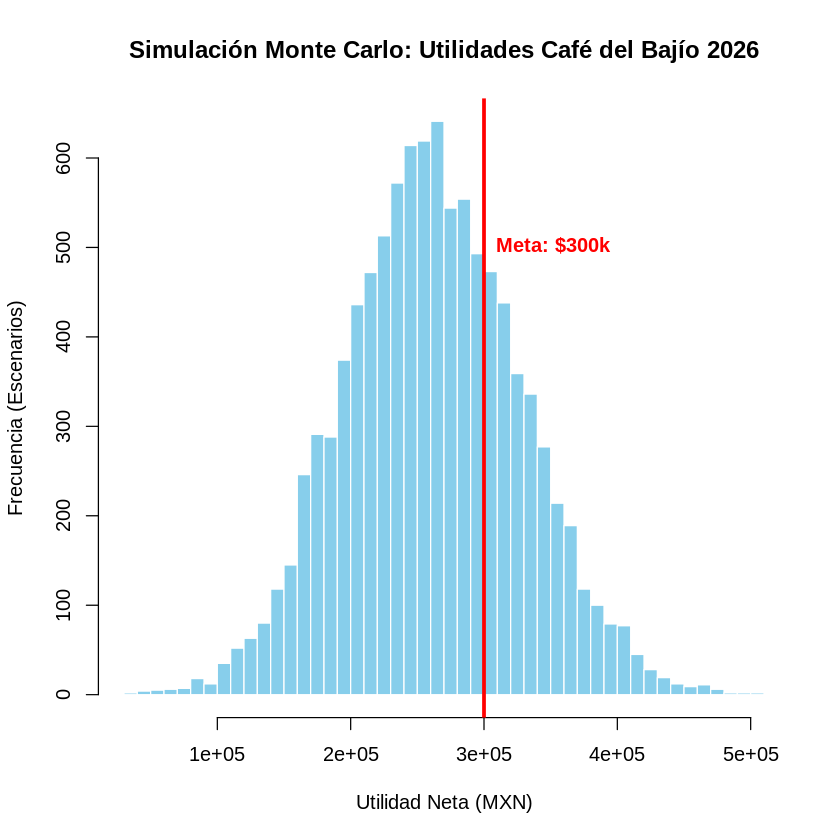

In [18]:
# PASO 5: Visualización de Resultados (Gráfico)
hist(resultados$UtilidadNeta,
     breaks = 40,
     col = "skyblue",
     border = "white",
     main = "Simulación Monte Carlo: Utilidades Café del Bajío 2026",
     xlab = "Utilidad Neta (MXN)",
     ylab = "Frecuencia (Escenarios)")

# Línea roja en la meta de $300,000
abline(v = 300000, col = "red", linetype = 2, lwd = 3)
text(x = 300000, y = n_sim * 0.05, "Meta: $300k", col = "red", pos = 4, font = 2)